# Chapter 22. Vectorized String operations in Pandas

Pandas includes features to handle vectorized string operations.
This is achieved via the `.str` attribute of a `Series` or `Index` objects.

For example, the following will apply capitalization to all strings in a series, and properly handle _missing data_:

In [2]:
import pandas as pd

data = ['peter', 'Paul', None, 'MARY', 'gUIDO']   # Note the missing name in the third position

names = pd.Series(data)
names.str.capitalize()

0    Peter
1     Paul
2     None
3     Mary
4    Guido
dtype: object

### Pandas String methods

Many of Pandas' string methods mirror the built-in Python string functions. Some of the most common are: `len`, `lower`, `upper`, `islower`, `isupper`, `find`, `endswith`, `startswith`, `isnumeric`, `isalnum`, `isdecimal`, `zfill`, `isalpha`, `split`, `strip`, `rstrip`, `lstrip`, `isdigit`, `capitalize`, `isspace`.

Various of these methods return values. These could be string values, e.g.:

In [3]:
monte = pd.Series(['Graham Chapman', 'John Cleese', 'Terry Gilliam',
                           'Eric Idle', 'Terry Jones', 'Michael Palin'])

monte.str.lower()
monte.str.len()
monte.str.find('ee')

0   -1
1    7
2   -1
3   -1
4   -1
5   -1
dtype: int64

Other methods return numbers:

In [4]:
monte.str.len()

0    14
1    11
2    13
3     9
4    11
5    13
dtype: int64

And others return Booleans:

In [5]:
monte.str.startswith('T')

0    False
1    False
2     True
3    False
4     True
5    False
dtype: bool

Still others return lists or other compound values:

In [6]:
monte.str.split()

0    [Graham, Chapman]
1       [John, Cleese]
2     [Terry, Gilliam]
3         [Eric, Idle]
4       [Terry, Jones]
5     [Michael, Palin]
dtype: object

### Regular expressions

In addition to standard string methods, Pandas also implements regular expression (`re`) matching to string objects, for example:

- `match` - Calls `re.match`, searching for a pattern in the string.
- `replace` - Replaces ocurrences of pattern with some other string.
- `count` - Counts occurrences of an input pattern in a string.

For instance, the following extract the first name from each element in the `Series`:

In [11]:
monte.str.extract('([A-Za-z]+)', expand=False)
monte.str.replace('([A-Za-z])+', '-', regex=True)

0    - -
1    - -
2    - -
3    - -
4    - -
5    - -
dtype: object

### Vectorized string slicing

It is possible to perform vectorized slicing using the `.str` attribute in a Pandas `Series`. The following returns a `Series` with only the first three characters of each name in the original `Series`:

In [10]:
monte.str[0:3]

0    Gra
1    Joh
2    Ter
3    Eri
4    Ter
5    Mic
dtype: object

# Chapter 23. Time series



## Native Python dates and times: `datetime` and `dateutil`

The `datetime` module allows the manipulation of dates and times in python: 

In [12]:
from datetime import datetime

datetime(year=2021, month=7, day=4)

datetime.datetime(2021, 7, 4, 0, 0)

The `dateutil` module has interfaces to automatically convert strings in certain format into `datetime` objects.

In [13]:
from dateutil import parser

date = parser.parse("4th of July, 2021")
date

datetime.datetime(2021, 7, 4, 0, 0)

### NumPy's `datetime64`


NumPy provides a data type for handling datetimes with 64-bits of precision:

In [14]:
import numpy as np

date = np.array('2021-07-04', dtype=np.datetime64)
date

array('2021-07-04', dtype='datetime64[D]')

Once a NumPy datetime object is created, we can apply vectorized operations to it:

In [15]:
date + np.arange(12)

array(['2021-07-04', '2021-07-05', '2021-07-06', '2021-07-07',
       '2021-07-08', '2021-07-09', '2021-07-10', '2021-07-11',
       '2021-07-12', '2021-07-13', '2021-07-14', '2021-07-15'],
      dtype='datetime64[D]')

### Dates and times in Pandas

Pandas offers an interface for handling dates and times similar to `np.datetime64`:

In [16]:
import pandas as pd

date = pd.to_datetime("4th of July, 2021, 1:00 PM")
date

Timestamp('2021-07-04 13:00:00')

We can use `.strftime()` to print a `datetime` object as a string. The following gets the day of the week (`'%A'`) from a `datetime`:

In [22]:
date.strftime('%A %Y-%b-%d %H:%M:%S')

'Sunday 2021-Jul-04 13:00:00'

Pandas also allows for vectorized date manipulation:

In [31]:
date + pd.to_timedelta(np.arange(12), 'D')

DatetimeIndex(['2021-07-04 13:00:00', '2021-07-05 13:00:00',
               '2021-07-06 13:00:00', '2021-07-07 13:00:00',
               '2021-07-08 13:00:00', '2021-07-09 13:00:00',
               '2021-07-10 13:00:00', '2021-07-11 13:00:00',
               '2021-07-12 13:00:00', '2021-07-13 13:00:00',
               '2021-07-14 13:00:00', '2021-07-15 13:00:00'],
              dtype='datetime64[ns]', freq=None)

## Pandas Time Series: Indexing by time

Let us contruct a `Series` object that has time-indexed data:

In [32]:
index = pd.DatetimeIndex(['2020-07-04', '2020-08-04',
                                   '2021-07-04', '2021-08-04'])
data = pd.Series([0, 1, 2, 3], index=index)
data

2020-07-04    0
2020-08-04    1
2021-07-04    2
2021-08-04    3
dtype: int64

Now that the dates are indices, we can use `Series` indexing patterns to filter the data, coercing strings into dates:

In [33]:
data['2020-07-04':'2021-07-04']

2020-07-04    0
2020-08-04    1
2021-07-04    2
dtype: int64

There are special indexing operations, such as passing a year. Doing this will return a slice of the data from that year:

In [34]:
data['2021']

2021-07-04    2
2021-08-04    3
dtype: int64

## Pandas time series data structures

- For _timestamps_, Pandas provides the `Timestamp` type.
- For _time periods_, Pandas provides the `Period` type.
- For _time deltas_ or _durations_, Pandas provides the `Timedelta` type.

Creating `Timestamp` objects with `.to_datetime`:

In [35]:
dates = pd.to_datetime([datetime(2021, 7, 3), '4th of July, 2021',
                                '2021-Jul-6', '07-07-2021', '20210708'])
dates

DatetimeIndex(['2021-07-03', '2021-07-04', '2021-07-06', '2021-07-07',
               '2021-07-08'],
              dtype='datetime64[ns]', freq=None)

You can also provide a format to be interpreted by Pandas `to_datetime`.
The `format` argument expects a string describing how the date string is constructed (this is also called `strftime`).
Using placeholders as:
- `'%Y'`: year with 4 digits.
- `'%d'`: day of month with 2 digits (1-31).
- `'%m'`: numerical representation of the month with 2 digits (1-12).
- `'%H'`: hours in 24h format.
- `'%M'`: minutes with 2 digits.
- `'%S'`: seconds with 2 digits.
- `'%A'`: Day of the week.
- `'%B'`: Month as a string.

Example:

In [36]:
dates_fmt = pd.to_datetime(['2025-02-03', '2025-11-01', '2025-01-11'], format='%Y-%d-%m')
dates_fmt

DatetimeIndex(['2025-03-02', '2025-01-11', '2025-11-01'], dtype='datetime64[ns]', freq=None)

Converting `Timestamp` to `Period`. `'D`' indicates that the periods correspond to one day.

In [37]:
dates.to_period('D')

PeriodIndex(['2021-07-03', '2021-07-04', '2021-07-06', '2021-07-07',
             '2021-07-08'],
            dtype='period[D]')

a `TimedeltaIndex` is created when a date is subtracted from another:

In [38]:
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[ns]', freq=None)

### Regular date sequences: `pd.date_range`

To create a sequence of dates, Pandas offers the `pd.date_range` method. It works similarly to Python's built-in `range` and `np.range`, taking in a start point, an end point, and a step size:

In [39]:
pd.date_range('2015-07-03', '2015-07-10')

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10'],
              dtype='datetime64[ns]', freq='D')

Alternatively, a `date_range` can be created with a start point and the number of periods:

In [40]:
pd.date_range('2015-07-03', periods=8)

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10'],
              dtype='datetime64[ns]', freq='D')

The default frequency is daily (`'D'`). This can be modified by altering the `freq` argument. For instance, to get hourly timestamps:

In [41]:
pd.date_range('2015-07-03', periods=8, freq='h')

DatetimeIndex(['2015-07-03 00:00:00', '2015-07-03 01:00:00',
               '2015-07-03 02:00:00', '2015-07-03 03:00:00',
               '2015-07-03 04:00:00', '2015-07-03 05:00:00',
               '2015-07-03 06:00:00', '2015-07-03 07:00:00'],
              dtype='datetime64[ns]', freq='h')

### Frequencies and offsets

Here is a non-comprehensive list of date frequencies:

- `D` - Calendar day
- `W` - Weekly
- `ME` - Month-end
- `YE` - Year end
- `H` - Hourly
- `T` - Minutes
- `S` - Seconds
- `L` - Milliseconds

### Resampling

It is often useful to aggregate date over a small period of time when dealing with long time series. This process is called _resampling_. The method is called `.resample`:

In [42]:
import pandas as pd

# Create a time series
rng = pd.date_range('2025-01-01', periods=100, freq='D')
ts = pd.Series(range(len(rng)), index=rng)

# Print time series before resampling
print(ts)


2025-01-01     0
2025-01-02     1
2025-01-03     2
2025-01-04     3
2025-01-05     4
              ..
2025-04-06    95
2025-04-07    96
2025-04-08    97
2025-04-09    98
2025-04-10    99
Freq: D, Length: 100, dtype: int64


In [43]:
# Resample to monthly frequency, taking the mean
monthly_mean = ts.resample('ME').mean()
print(monthly_mean)

2025-01-31    15.0
2025-02-28    44.5
2025-03-31    74.0
2025-04-30    94.5
Freq: ME, dtype: float64


In [44]:

# Resample to weekly mean
weekly_mean = ts.resample('W').mean()
print(weekly_mean)

2025-01-05     2.0
2025-01-12     8.0
2025-01-19    15.0
2025-01-26    22.0
2025-02-02    29.0
2025-02-09    36.0
2025-02-16    43.0
2025-02-23    50.0
2025-03-02    57.0
2025-03-09    64.0
2025-03-16    71.0
2025-03-23    78.0
2025-03-30    85.0
2025-04-06    92.0
2025-04-13    97.5
Freq: W-SUN, dtype: float64


## Quick plots with Pandas

We can quickly generate simple plots using Pandas DataFrames and Series by invoking the `.plot()` method. Let us visualize the weekly mean results as a graph:

<Axes: xlabel='Date', ylabel='Weekly mean'>

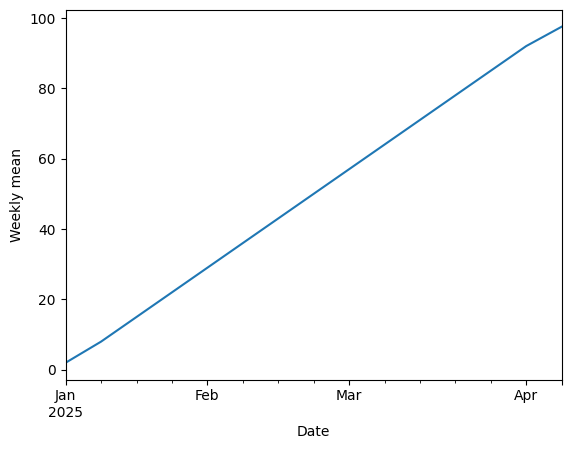

In [45]:
weekly_mean.plot(xlabel='Date', ylabel='Weekly mean')

The `plot()` method accepts parameter `kind` which is used to determine the type of plot to be generated, such as `'line'` (default), `'scatter'`, `'bar'`, etc:

<Axes: xlabel='Date', ylabel='Weekly mean'>

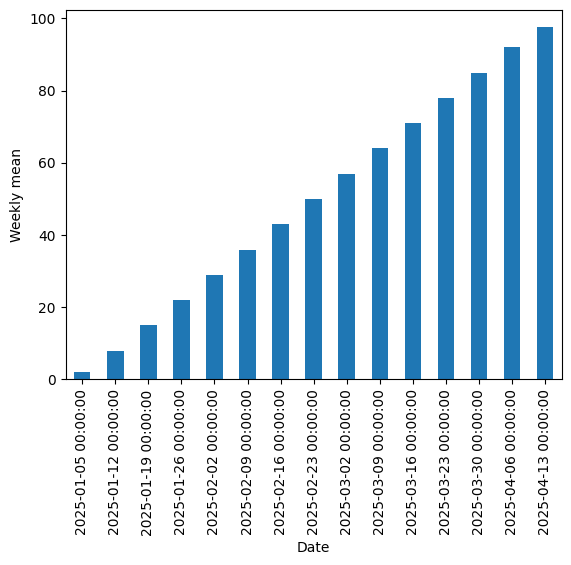

In [46]:
weekly_mean.plot(xlabel='Date', ylabel='Weekly mean', kind='bar')

### Plotting multiple columns on a single graph

Using a DataFrame, we can plot various columns on the same graph. The following plots two different sets of values (y-axis) over the same date range (x-axis):

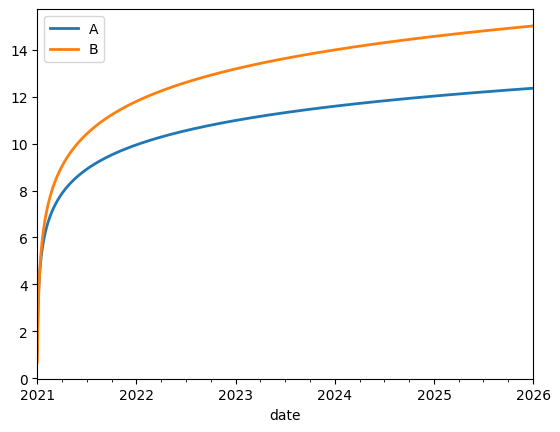

In [47]:
import pandas as pd
import numpy as np

dates = pd.date_range('2021-01-01', '2026-01-01')
col_a = np.log(3*np.arange(1, len(dates)+1)**(3/2))  # Generate random values 
col_b = np.log(1+np.arange(1, len(dates)+1)**2)

df = pd.DataFrame(
    {"date": dates,
     "A": col_a,
     "B": col_b}
)

# Plot lines for columns A and B, using 'date' as the horizontal axis.
df.plot(kind='line', x='date', y=['A', 'B'], linewidth=2);

Or we can separate the curves into subplots:

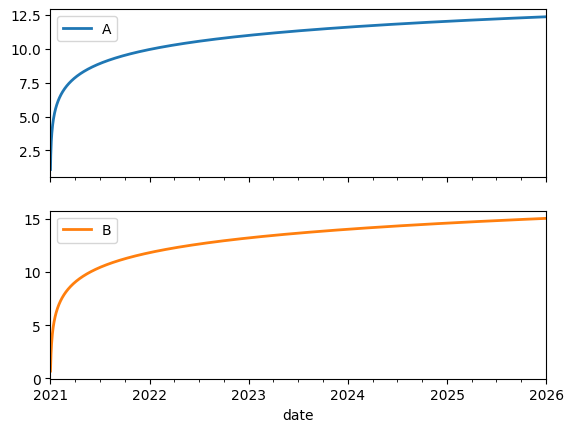

In [48]:
df.plot(kind='line', x='date', y=['A', 'B'], linewidth=2, subplots=True);